In [43]:
# load gaussian_annealing_naive_unweighted
import os
import pickle
import sys 

sys.path.append('.')
sys.path.append('..')
sys.path.append('../data')
# from src.plotting import create_all_plots

# print(os.listdir('../data'))

# data = pickle.load(open('polynomial/double_well/leapfrog/cd_unweighted.pkl', 'rb'))


In [2]:
# data['snapshots']['times']

/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_99181/276925691.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x)  # Normalize


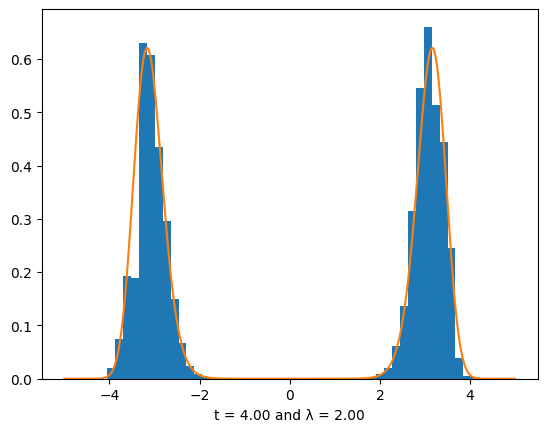

In [52]:
# plot a gaussian with unit variance, 1D
import numpy as np
import matplotlib.pyplot as plt
from src.systems import SYSTEMS

# y is a normal pdf (scipy) with std 0.1
from scipy.stats import norm
from src.utils import normalize_log_weights
# y = norm.pdf(x, 0, 1/0.5)



def make_hist(file, i):
    data = pickle.load(open(file, 'rb'))

    x = np.linspace(-5, 5, 1000)


    times = data['snapshots']['times']
    lambdas = data['snapshots']['lam']
    potential = SYSTEMS['double_well']['make_V'](lambdas[i])


    y = potential(x)
    # normalize y using trapezoid integration
    rho = np.array([np.exp(-potential(point)) for point in x])
    rho = rho / np.trapz(rho, x)  # Normalize

    # print(times[i])

    particles = data['snapshots']['particles']
    log_weights = data['snapshots']['weights'][i]
    weights = np.exp(normalize_log_weights(log_weights))
    
    plt.hist(particles[i][:,0], bins=50, weights=weights, density=True)
    plt.plot(x, rho)
    plt.xlabel(f't = {times[i]:.2f} and λ = {lambdas[i]:.2f}')
    plt.show()

# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=0)
# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=20)
make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=20)